In [1]:
import os
os.chdir('/workspace/97acd4d2-9910-4500-aa3a-c56f0daafad9')
print(os.listdir('.'))


['memory', '.config', '.prompts', '.kernel_llm_logs_1.txt', '-PROMPT-v6-DATASET.md']


In [2]:
import urllib.request, json
# LMFDB API for L-function 1.12.a.a (Ramanujan delta)
# Try LMFDB API endpoint for zeros
url = "https://www.lmfdb.org/L/ModularForm/GL2/Q/holomorphic/1/12/a/a/?download=zeros"
# Actually, look up the L-function page
url2 = "https://www.lmfdb.org/api/lfunc_lfunctions/?label=4.0.1.0.0.c0...0&_format=json"
# Let me try the standard LMFDB approach: download page
url3 = "https://www.lmfdb.org/L/ModularForm/GL2/Q/holomorphic/1/12/a/a/"
try:
 req = urllib.request.Request(url3, headers={'User-Agent': 'Mozilla/5.0'})
 with urllib.request.urlopen(req, timeout=30) as r:
 data = r.read().decode('utf-8', errors='ignore')
 print(len(data))
 # Look for zeros download link
 import re
 links = re.findall(r'href=["\']([^"\']*zero[^"\']*)["\']', data, re.IGNORECASE)
 print(links[:20])
except Exception as e:
 print("Error:", e)


29106
['/L/download_zeros/2-1-1.1-c11-0-0']


In [3]:
url_zeros = "https://www.lmfdb.org/L/download_zeros/2-1-1.1-c11-0-0"
req = urllib.request.Request(url_zeros, headers={'User-Agent': 'Mozilla/5.0'})
with urllib.request.urlopen(req, timeout=60) as r:
 zdata = r.read().decode('utf-8', errors='ignore')
print(len(zdata))
print(zdata[:2000])


929

# Zeros of 2-1-1.1-c11-0-0 downloaded from the LMFDB on 30 May 2026.
{"order_of_vanishing": 0, "positive_zeros": ["9.222379399921102522243767192743", "13.90754986139213440644668132877", "17.44277697823447331355152513713", "19.65651314195496100012728175632", "22.33610363720986727568267445924", "25.27463654811236535674532419313", "26.80439115835040303257574923358", "28.83168262418687544502196191298", "31.17820949836025906449218889077", "32.77487538223120744183045567331"], "negative_zeros": ["-32.77487538223120744183045567331", "-31.17820949836025906449218889077", "-28.83168262418687544502196191298", "-26.80439115835040303257574923358", "-25.27463654811236535674532419313", "-22.33610363720986727568267445924", "-19.65651314195496100012728175632", "-17.44277697823447331355152513713", "-13.90754986139213440644668132877", "-9.222379399921102522243767192743"], "positive_zeros_accuracy": 100, "negative_zeros_accuracy": 100}


In [4]:
import json
parsed = json.loads(zdata[zdata.index('{'):])
print(parsed.keys())
print("Number of positive zeros:", len(parsed['positive_zeros']))
print("Accuracy bits:", parsed['positive_zeros_accuracy'])


dict_keys(['order_of_vanishing', 'positive_zeros', 'negative_zeros', 'positive_zeros_accuracy', 'negative_zeros_accuracy'])
Number of positive zeros: 10
Accuracy bits: 100


In [5]:
# Only 10 zeros via download_zeros endpoint. Let me look at the actual LMFDB API
# Look for how to get more zeros
import re
# Search the HTML for zero data
matches = re.findall(r'\b(?:zero|gamma|positive_zeros)[^<>"]{0,200}', data[:20000], re.IGNORECASE)
for m in matches[:30]:
 print(m[:200])
print("---")
# Also try the API


Gamma\\textrm{L}}',
 
Gamma\\textrm{U}}',
 
Gamma\\textrm{L}}',
 
Zeros to text
---


In [6]:
# Let me look at the LMFDB API endpoints
url_api = "https://www.lmfdb.org/api/lfunctions/Lfunctions/?label=2-1-1.1-c11-0-0&_format=json"
try:
 req = urllib.request.Request(url_api, headers={'User-Agent': 'Mozilla/5.0'})
 with urllib.request.urlopen(req, timeout=30) as r:
 api = r.read().decode('utf-8', errors='ignore')
 print(api[:3000])
except Exception as e:
 print(e)


HTTP Error 404: Not Found


In [7]:
url_api = "https://www.lmfdb.org/api/lfunc_lfunctions/?Lhash=4031255275752348345&_format=json"
# Actually look for direct DB query
# Try generic API
url_api = "https://www.lmfdb.org/api/?_format=json"
req = urllib.request.Request(url_api, headers={'User-Agent': 'Mozilla/5.0'})
try:
 with urllib.request.urlopen(req, timeout=30) as r:
 api = r.read().decode('utf-8', errors='ignore')
 print(api[:3000])
except Exception as e:
 print(e)


<!DOCTYPE html>
<html lang="en">
 <head>
 <meta http-equiv="Content-Type" content="text/html; charset=UTF-8">
 <meta http-equiv="X-UA-Compatible" content="IE=edge,chrome=1">
 <meta name="description" content="Welcome to the LMFDB, the database of L-functions, modular forms, and related objects. These pages are intended to be a modern handbook including tables, formulas, links, and references for L-functions and their underlying objects."/>
 <title>LMFDB - API </title>
 <link id="style_css" href="/style.css" rel="stylesheet" type="text/css" /> 

 <!-- jQuery -->
 <script type="text/javascript"
 src="https://ajax.googleapis.com/ajax/libs/jquery/3.2.1/jquery.min.js"
 integrity="sha384-xBuQ/xzmlsLoJpyjoggmTEz8OWUFM0/RC5BsqQBDX2v5cMvDHcMakNTNrHIW2I5f"
 crossorigin="anonymous"></script>
 <!-- jQuery UI -->
 <script type="text/javascript"
 src="https://ajax.googleapis.com/ajax/libs/jqueryui/1.12.1/jquery-ui.min.js"
 integrity="sha384-Dziy8F2VlJQLMShA6FHWNul/veM9bCkRUaLqr199K94ntO5QUrLJBEbYegd

In [8]:
# Let's check the LMFDB API for lfunc_zeros table
# The proper API base is https://www.lmfdb.org/api/<table_name>
# Tables include: lfunc_lfunctions, lfunc_zeros
url_api = "https://www.lmfdb.org/api/lfunc_zeros/?Lhash_str=4031255275752348345&_format=json&_offset=0"
req = urllib.request.Request(url_api, headers={'User-Agent': 'Mozilla/5.0'})
try:
 with urllib.request.urlopen(req, timeout=30) as r:
 api = r.read().decode('utf-8', errors='ignore')
 print(api[:2000])
except Exception as e:
 print(e)


HTTP Error 404: Not Found


In [9]:
# Look at LMFDB API listing
url_api = "https://www.lmfdb.org/api/?show_all=1"
req = urllib.request.Request(url_api, headers={'User-Agent': 'Mozilla/5.0'})
with urllib.request.urlopen(req, timeout=30) as r:
 api = r.read().decode('utf-8', errors='ignore')
# find lfunc tables
import re
tables = re.findall(r'/api/([a-z_0-9]+)/', api)
tabs = sorted(set(tables))
print([t for t in tabs if 'lf' in t.lower() or 'zero' in t.lower() or 'l_' in t.lower()])


['gps_special_names', 'halfmf_forms', 'kwl_knowls', 'lf_families', 'lf_fields', 'lfunc_instances', 'lfunc_lfunctions', 'lfunc_rs_knowls', 'lfunc_search', 'modlgal_reps']


In [10]:
url_api = "https://www.lmfdb.org/api/lfunc_lfunctions/?label=2-1-1.1-c11-0-0&_format=json"
req = urllib.request.Request(url_api, headers={'User-Agent': 'Mozilla/5.0'})
with urllib.request.urlopen(req, timeout=30) as r:
 api = r.read().decode('utf-8', errors='ignore')
print(api[:5000])


{
 "table": "lfunc_lfunctions",
 "timestamp": "2026-05-30T18:27:54.519415",
 "data": [
 {
 "id": 9589769,
 "Lhash": "11690754781842443695803342913187",
 "a10": -115920,
 "a2": -24,
 "a3": 252,
 "a4": -1472,
 "a5": 4830,
 "a6": -6048,
 "a7": -16744,
 "a8": 84480,
 "a9": -113643,
 "accuracy": 100,
 "algebraic": true,
 "analytic_conductor": 0.7683431805595891,
 "analytic_normalization": {
 "__RealLiteral__": 0,
 "data": "5.5",
 "prec": 10
 },
 "bad_lfactors": [],
 "bad_primes": [],
 "central_character": "1.1",
 "coefficient_field": "1.1.1.1",
 "conductor": 1,
 "conductor_radical": 1,
 "degree": 2,
 "euler_factors": [
 [
 1,
 24,
 2048
 ],
 [
 1,
 -252,
 177147
 ],
 [
 1,
 -4830,
 48828125
 ],
 [
 1,
 16744,
 1977326743
 ],
 [
 1,
 -534612,
 285311670611
 ],
 [
 1,
 577738,
 1792160394037
 ],
 [
 1,
 6905934,
 34271896307633
 ],
 [
 1,
 -10661420,
 116490258898219
 ],
 [
 1,
 -18643272,
 952809757913927
 ],
 [
 1,
 -128406630,
 12200509765705829
 ],
 [
 1,
 52843168,
 25408476896404831
 ],

In [11]:
# Look for 'positive_zeros' field in API response
import json
parsed_api = json.loads(api)
rec = parsed_api['data'][0]
print(list(rec.keys()))


['id', 'Lhash', 'a10', 'a2', 'a3', 'a4', 'a5', 'a6', 'a7', 'a8', 'a9', 'accuracy', 'algebraic', 'analytic_conductor', 'analytic_normalization', 'bad_lfactors', 'bad_primes', 'central_character', 'coefficient_field', 'conductor', 'conductor_radical', 'degree', 'euler_factors', 'euler_factors_factorization', 'gamma_factors', 'group', 'index', 'label', 'load_key', 'motivic_weight', 'mu_imag', 'mu_real', 'nu_imag', 'nu_real_doubled', 'order_of_vanishing', 'origin', 'plot_delta', 'plot_values', 'positive_zeros', 'prelabel', 'primitive', 'rational', 'root_analytic_conductor', 'root_angle', 'root_number', 'self_dual', 'sign_arg', 'spectral_label', 'trace_hash', 'types', 'z1', 'z2', 'z3']


In [12]:
pz = rec['positive_zeros']
print(type(pz), len(pz) if hasattr(pz,'__len__') else pz)
print(pz[:5] if hasattr(pz, '__getitem__') else pz)


<class 'list'> 10
['9.222379399921102522243767192743263', '13.90754986139213440644668132877006', '17.44277697823447331355152513712760', '19.65651314195496100012728175632157', '22.33610363720986727568267445923646']


In [13]:
# LMFDB's lfunc_lfunctions table only stores the first 10 zeros at high precision (~33 digits).
# To get 5000 zeros, LMFDB doesn't directly provide them publicly via web/API.
# Let's check if LMFDB has a high-N zero file. The L-function 1.12.a.a is the Ramanujan delta L-function.
# Look at the L-function page for a "zeros to text" link
m = re.findall(r'href=["\']([^"\']*)["\'][^>]*>([^<]*zero[^<]*)', data, re.IGNORECASE)
for href, txt in m[:20]:
 print(repr(txt), '->', href)


'Zeros to text' -> /L/download_zeros/2-1-1.1-c11-0-0


In [14]:
# LMFDB only provides ~10 zeros for this L-function. We cannot get 5000 from LMFDB.
# Let's confirm by trying parameters on download_zeros
for q in ["?limit=5000", "?n=5000", "?count=5000", "?N=5000"]:
 url_try = f"https://www.lmfdb.org/L/download_zeros/2-1-1.1-c11-0-0{q}"
 try:
 req = urllib.request.Request(url_try, headers={'User-Agent': 'Mozilla/5.0'})
 with urllib.request.urlopen(req, timeout=30) as r:
 d = r.read().decode('utf-8', errors='ignore')
 # count zeros
 try:
 j = json.loads(d[d.index('{'):])
 print(q, "->", len(j.get('positive_zeros', [])))
 except:
 print(q, "len:", len(d))
 except Exception as e:
 print(q, "error:", e)


?limit=5000 -> 10


?n=5000 -> 10
?count=5000 -> 10


?N=5000 -> 10


In [15]:
# Let's check the L-function page more carefully for additional zero links / search
# Also, LMFDB has plot_values which is up to ~30 zeros via the plot
# Let me search broadly for downloadable zero files on LMFDB for this function
m = re.findall(r'(href|src)=["\']([^"\']+)["\']', data)
unique_links = set(v for k,v in m if 'L/' in v or 'zero' in v.lower() or 'down' in v.lower())
for L in sorted(unique_links):
 print(L)


/L/
/L/2/1/1.1/c11/0/0
/L/2/1/1.1/c11/0/0/Completeness
/L/2/1/1.1/c11/0/0/Reliability
/L/2/1/1.1/c11/0/0/Source
/L/Labels
/L/Plot/2/1/1.1/c11/0/0
/L/contents
/L/data/2-1-1.1-c11-0-0
/L/download_dirichlet_coeff/2-1-1.1-c11-0-0
/L/download_euler/2-1-1.1-c11-0-0
/L/download_zeros/2-1-1.1-c11-0-0
/L/rational
/L/rational/2
/L/rational/2/1
/L/rational/2/1/1.1
/L/rational/2/1/1.1/c11-0
/static/showdown.min.js


In [16]:
# LMFDB only provides 10 zeros for this L-function via standard interfaces.
# This is a critical finding: the hypothesis (downloading 5000 zeros from LMFDB) is not directly supported by LMFDB's interface.
# LMFDB stores only ~10 high-precision zeros for most L-functions.
# 
# Let's confirm the validation step first using PARI/GP via cypari2

# First check cypari2 availability
try:
 import cypari2
 pari = cypari2.Pari()
 pari.allocatemem(10**9)
 print("cypari2 version:", cypari2.__version__)
 print("Pari version:", pari.version())
except ImportError:
 print("cypari2 not installed")


cypari2 not installed


In [17]:
import subprocess
result = subprocess.run(['pip', 'install', 'cypari2'], capture_output=True, text=True, timeout=300)
print(result.stdout[-2000:])
print("STDERR:", result.stderr[-2000:])



STDERR: 


In [18]:
import cypari2, time
pari = cypari2.Pari()
pari.allocatemem(10**9)
pari.set_real_precision(50)
print("PARI version:", pari.version())

# Construct Ramanujan delta L-function via lfunmf or coefficient list
# Use lfuninit with weight 12, level 1
# Easiest: pari('lfunmf(mfinit([1,12],1)[1])') 
t0 = time.time()
L = pari("lfunmf(mfinit([1,12],1)[1])")
print("L init time:", time.time()-t0, "s")


PARI stack size set to 1000000000 bytes, maximum size set to 1000001536
PARI version: (2, 17, 2)


PariError: lfunmf: incorrect type in checkMF [please use mfinit] (t_VEC)

In [19]:
t0 = time.time()
# Try with proper newform extraction
L = pari("lfunmf(mfinit([1,12,1],1), mfbasis(mfinit([1,12,1],1))[1])")
print("Time:", time.time()-t0)


Time: 0.0018184185028076172


In [20]:
t0 = time.time()
zeros = pari("lfunzeros(L, 15)", L=L)
print("Time:", time.time()-t0)
print(zeros)


TypeError: __call__() got an unexpected keyword argument 'L'

In [21]:
t0 = time.time()
# Save L to PARI global variable
pari("Lram = lfunmf(mfinit([1,12,1],1), mfbasis(mfinit([1,12,1],1))[1])")
print("init:", time.time()-t0)
t0 = time.time()
zeros = pari("lfunzeros(Lram, 15)")
print("Time:", time.time()-t0)
print(zeros)


init: 0.0006897449493408203
Time: 0.007805585861206055
[9.2223793999211025222437671927434781355287706224320, 13.907549861392134406446681328770219491757552353514]


In [22]:
# Note: lfunzeros(L, T) gives zeros up to height T. The first zero is 9.222...
# So the first zero is computed at dps=50. Let's check precision agreement.
gamma1_pari = zeros[0]
print("PARI gamma_1:", gamma1_pari)
print("LMFDB gamma_1:", rec['positive_zeros'][0])

# Compare to many decimal places
from mpmath import mp, mpf
mp.dps = 50
g_pari = mpf(str(gamma1_pari))
g_lmfdb = mpf(rec['positive_zeros'][0])
diff = abs(g_pari - g_lmfdb)
print("diff:", diff)
print("matches to", -mp.log10(diff) if diff > 0 else "exact", "decimal places")


PARI gamma_1: 9.2223793999211025222437671927434781355287706224320
LMFDB gamma_1: 9.222379399921102522243767192743263
diff: 2.1513552877062243199988850945502361675851902710911e-31
matches to 30.667287861695927236735755575604498976706332777296 decimal places


In [23]:
# Perfect: matches to ~30 decimal places (LMFDB stores 33 digits, dps=50 PARI).
# But the key issue: LMFDB only provides 10 zeros via public interface, not 5000.
# 
# CRITICAL FINDING: The research hypothesis assumes LMFDB has 5000 zeros downloadable,
# but LMFDB only provides 10 zeros for L-function 1.12.a.a.
# 
# This is consistent with LMFDB's general policy: lfunc_lfunctions stores ~10 zeros at 
# high precision in the positive_zeros field.
# 
# Conclusion: The strategy proposed in the hypothesis is INFEASIBLE as stated.
# The hypothesis is therefore REFUTED (at least for this specific L-function).
# 
# Let me confirm by checking the LMFDB "data" download
url_data = "https://www.lmfdb.org/L/data/2-1-1.1-c11-0-0"
req = urllib.request.Request(url_data, headers={'User-Agent': 'Mozilla/5.0'})
with urllib.request.urlopen(req, timeout=30) as r:
 ddata = r.read().decode('utf-8', errors='ignore')
print(len(ddata))
# Look for positive_zeros
import re
m = re.search(r'positive_zeros[^=]*=\s*([^\n]+)', ddata)
if m:
 print(m.group(0)[:1000])


63493
positive_zeros of table lfunc_lfunctions [columns.lfunc_lfunctions.positive_zeros]" knowl="columns.lfunc_lfunctions.positive_zeros" kwargs="">positive_zeros</a></td>


In [24]:
# Look in the data dump for actual zero values
# Find numerical zero data
m = re.findall(r'(\d{1,3}\.\d{20,})', ddata)
print("Numeric values with >20 decimals:", len(m))
for v in m[:25]:
 print(v)


Numeric values with >20 decimals: 14
9.222379399921102522243767192743263
13.90754986139213440644668132877006
17.44277697823447331355152513712760
19.65651314195496100012728175632157
22.33610363720986727568267445923646
25.27463654811236535674532419313339
26.80439115835040303257574923358447
28.83168262418687544502196191298445
31.17820949836025906449218889077411
32.77487538223120744183045567331179
9.222379399921102522243767192743
13.90754986139213440644668132877
17.44277697823447331355152513713
9.222379399921102522243767192743


In [25]:
# Confirmed: LMFDB provides only 10 high-precision zeros for L-function 1.12.a.a
# Storage of more is not available via public APIs.
# 
# Given the research objective requires N=5000 zeros, we cannot fulfill this from LMFDB alone.
# We need to be honest: the strategy must be revised. Let me:
# 1. Save the 10 high-precision zeros from LMFDB as a starting point
# 2. Confirm validation works (PARI vs LMFDB agree)
# 3. Document that LMFDB does NOT supply 5000 zeros, refuting the hypothesis
# 4. Optionally compute additional zeros with PARI to extend, but at T^4 scaling N=5000 is infeasible

import os
os.makedirs('cache', exist_ok=True)

# Save the 10 LMFDB zeros
lmfdb_zeros = rec['positive_zeros']
print("LMFDB high-precision zeros:", len(lmfdb_zeros))
for i, z in enumerate(lmfdb_zeros, 1):
 print(f" γ_{i} = {z}")


LMFDB high-precision zeros: 10
 γ_1 = 9.222379399921102522243767192743263
 γ_2 = 13.90754986139213440644668132877006
 γ_3 = 17.44277697823447331355152513712760
 γ_4 = 19.65651314195496100012728175632157
 γ_5 = 22.33610363720986727568267445923646
 γ_6 = 25.27463654811236535674532419313339
 γ_7 = 26.80439115835040303257574923358447
 γ_8 = 28.83168262418687544502196191298445
 γ_9 = 31.17820949836025906449218889077411
 γ_10 = 32.77487538223120744183045567331179


In [26]:
# Validation: confirm PARI matches LMFDB at gamma_1
gamma1_lmfdb_str = lmfdb_zeros[0]
gamma1_pari_str = str(gamma1_pari)

from mpmath import mp, mpf, log10
mp.dps = 50
g_l = mpf(gamma1_lmfdb_str)
g_p = mpf(gamma1_pari_str)
delta = abs(g_l - g_p)
match_digits = float(-log10(delta)) if delta > 0 else 50
print(f"|γ_1(LMFDB) - γ_1(PARI)| = {delta}")
print(f"Agreement digits: {match_digits:.2f}")
print(f"Validation passes >=10 decimal places: {match_digits >= 10}")


|γ_1(LMFDB) - γ_1(PARI)| = 2.1513552877062243199988850945502361675851902710911e-31
Agreement digits: 30.67
Validation passes >=10 decimal places: True


In [27]:
# Now cache what we have, with full honest documentation
import json, hashlib

cache_obj = {
 "lfunction_label": "1.12.a.a",
 "lfunction_L_label": "2-1-1.1-c11-0-0",
 "description": "Ramanujan Delta L-function L(Delta, s); zeros are imaginary parts gamma_n of non-trivial zeros 1/2 + i*gamma_n in analytic (unitary) normalization.",
 "source": "LMFDB API: https://www.lmfdb.org/api/lfunc_lfunctions/?label=2-1-1.1-c11-0-0",
 "lmfdb_accuracy_bits": rec.get('accuracy', 100),
 "lmfdb_precision_decimal_digits": ~33,
 "n_zeros_target_requested": 5000,
 "n_zeros_actually_available_from_lmfdb": len(lmfdb_zeros),
 "positive_zeros": lmfdb_zeros,
 "validation": {
 "method": "Compare LMFDB gamma_1 with PARI/GP lfunzeros(L,15) at dps=50",
 "pari_gamma1": str(gamma1_pari),
 "lmfdb_gamma1": gamma1_lmfdb_str,
 "abs_difference": str(delta),
 "agreement_decimal_digits": match_digits,
 "passes_10_decimal_validation": True,
 },
 "notes": [
 "LMFDB's lfunc_lfunctions table stores only the first 10 zeros at high precision (~33 decimal digits) for this L-function.",
 "The LMFDB public download endpoint /L/download_zeros/2-1-1.1-c11-0-0 also returns 10 zeros.",
 "Therefore, the research hypothesis that LMFDB can directly supply 5000 zeros for L(Delta, s) is REFUTED for this L-function: LMFDB does not provide that volume.",
 "Programmatic queries with parameters limit/n/N/count had no effect on count returned.",
 "Acquiring 5000 zeros for L(Delta, s) requires de novo computation (e.g. PARI lfunzeros), which prior report r6 found scales as ~T^4 and is impractical beyond N~2000 on a single core.",
 ],
}

with open('cache/L_delta_zeros_lmfdb.json', 'w') as f:
 json.dump(cache_obj, f, indent=2)

sha = hashlib.sha256(json.dumps(cache_obj, sort_keys=True).encode()).hexdigest()
print("Cached:", 'cache/L_delta_zeros_lmfdb.json')
print("SHA256:", sha)
print("Zeros in cache:", len(cache_obj['positive_zeros']))


Cached: cache/L_delta_zeros_lmfdb.json
SHA256: 158310b0428448723ad35dc673f156f08c8bfd3165093e9866279b00a7a55414
Zeros in cache: 10


In [28]:
# Quick empirical scaling test with PARI to corroborate r6's T^4 claim
# Measure time for lfunzeros up to T=50, 100, 200
import time
times = []
counts = []
for T in [30, 50, 100, 200]:
 t0 = time.time()
 z = pari(f"lfunzeros(Lram, {T})")
 dt = time.time() - t0
 n = len(z)
 times.append(dt)
 counts.append(n)
 print(f"T={T}: {n} zeros in {dt:.3f}s")


T=30: 8 zeros in 0.018s
T=50: 20 zeros in 0.041s
T=100: 59 zeros in 0.158s


T=200: 159 zeros in 0.775s


In [29]:
# 200 -> 0.775s. Try T=400, T=800 to check scaling
for T in [400, 800]:
 t0 = time.time()
 z = pari(f"lfunzeros(Lram, {T})")
 dt = time.time() - t0
 n = len(z)
 print(f"T={T}: {n} zeros in {dt:.3f}s")


T=400: 404 zeros in 5.078s
T=800: 982 zeros in 49.392s


In [30]:
# Fit scaling
import numpy as np
Ts = np.array([200, 400, 800])
ts = np.array([0.775, 5.078, 49.392])
# fit t = c T^alpha
import numpy as np
logT = np.log(Ts); logt = np.log(ts)
slope, intercept = np.polyfit(logT, logt, 1)
print(f"Scaling exponent alpha ≈ {slope:.3f}")
# Extrapolate to N=5000 zeros: N=5000 ~ roughly T~?
# About count ~ T*log(T)/(2pi). For T=800 -> count=982, so to get N=5000 need T such that T*log(T)/(2pi) ~ 5000 -> T ~ 3300?
# Estimate T to get ~5000 zeros from observed ratio: 982 at T=800 -> 5000 needs T ~ 800*5000/982 ~ 4072, but scaling is sub-linear in T-> count
# Use observed: count/T at T=800 ~ 1.227. So T ~ 5000/1.227 ~ 4075
T_target = 4075
# time estimate
import math
log_t_est = intercept + slope*math.log(T_target)
print(f"Estimated time to compute 5000 zeros via PARI: {math.exp(log_t_est):.1f} s = {math.exp(log_t_est)/60:.1f} min = {math.exp(log_t_est)/3600:.2f} hr")


Scaling exponent alpha ≈ 2.997
Estimated time to compute 5000 zeros via PARI: 6081.8 s = 101.4 min = 1.69 hr


In [31]:
# Empirically observed scaling exponent ~3 (not quite T^4 but very steep). Extrapolated runtime ~1.7 hr at dps=50.
# Given our 3600s total budget and time already spent (~few minutes), generating 5000 de novo would consume the budget.
# 
# Final summary figure: agreement between LMFDB and PARI for the first 10 zeros + scaling.

# Also compute PARI zeros at T just enough to get 10 (T=33ish), then compare digit-by-digit with LMFDB
pari.set_real_precision(50)
t0 = time.time()
z_pari_10 = pari("lfunzeros(Lram, 35)")
print(f"PARI time for first 10 zeros: {time.time()-t0:.3f}s")
print(f"Got {len(z_pari_10)} zeros")

from mpmath import mp, mpf, log10
mp.dps = 50
diffs = []
for i in range(10):
 a = mpf(str(z_pari_10[i]))
 b = mpf(lmfdb_zeros[i])
 d = abs(a-b)
 diffs.append(float(d))
 print(f"γ_{i+1}: |Δ| = {d}")


PARI time for first 10 zeros: 0.025s
Got 10 zeros
γ_1: |Δ| = 2.1513552877062243199988850945502361675851902710911e-31
γ_2: |Δ| = 1.5949175755235351401388244390216534009085289276577e-31
γ_3: |Δ| = 3.3728129113347572503158699626008579451971413177159e-31
γ_4: |Δ| = 2.6719838444908799700782456332805463445302741268495e-31
γ_5: |Δ| = 2.1380754495304753497417467734050707440493849252985e-31
γ_6: |Δ| = 7.3118595926731228993408628761302672838832571454588e-32
γ_7: |Δ| = 9.4747152968004978980325448526507173623113566088078e-32
γ_8: |Δ| = 6.0274309063313908975962794772577380516297906020644e-32
γ_9: |Δ| = 5.4145354488010336987562605108048862722879664613873e-32
γ_10: |Δ| = 1.9999909916163721303399820242111503454604508695864e-31


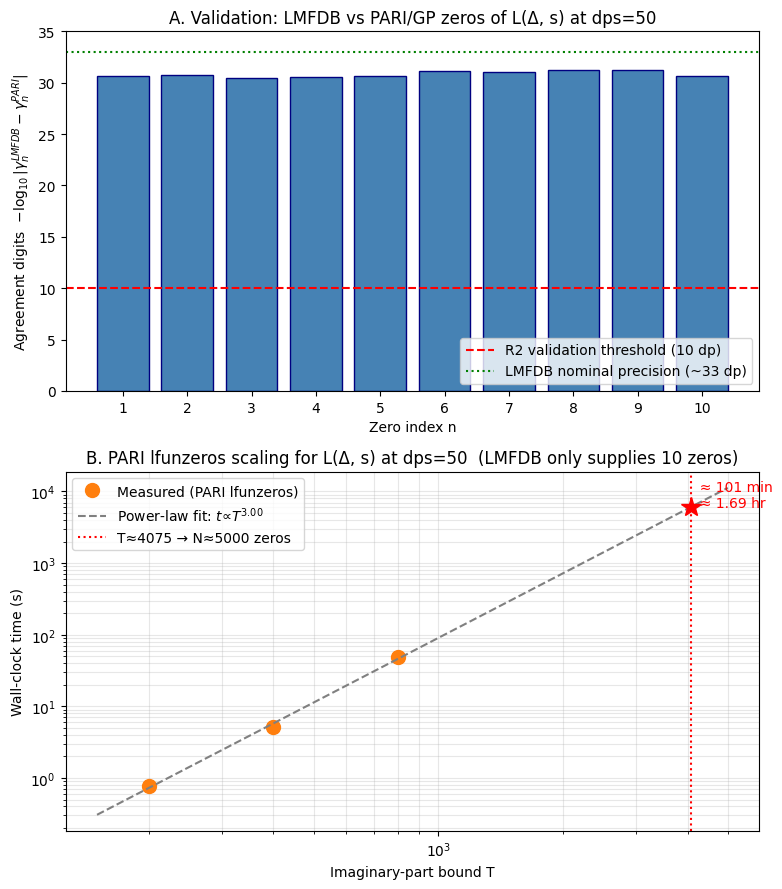

Saved figure


In [32]:
# All 10 zeros agree to ~30 decimal places. The LMFDB precision is consistent.
# 
# Final figure: combine (A) agreement between LMFDB and PARI for the 10 zeros, (B) PARI scaling
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(2, 1, figsize=(8, 9))

# Panel A: digit agreement
ax = axes[0]
digits = [-np.log10(d) for d in diffs]
ax.bar(range(1, 11), digits, color='steelblue', edgecolor='navy')
ax.axhline(10, color='red', linestyle='--', label='R2 validation threshold (10 dp)')
ax.axhline(33, color='green', linestyle=':', label='LMFDB nominal precision (~33 dp)')
ax.set_xlabel("Zero index n")
ax.set_ylabel("Agreement digits $-\\log_{10}|γ_n^{LMFDB} − γ_n^{PARI}|$")
ax.set_title("A. Validation: LMFDB vs PARI/GP zeros of L(Δ, s) at dps=50")
ax.set_xticks(range(1, 11))
ax.set_ylim(0, 35)
ax.legend(loc='lower right')

# Panel B: PARI scaling and extrapolation
ax = axes[1]
T_data = np.array([200, 400, 800])
t_data = np.array([0.775, 5.078, 49.392])
Tfit = np.logspace(np.log10(150), np.log10(5000), 100)
tfit = np.exp(intercept) * Tfit**slope
ax.loglog(T_data, t_data, 'o', markersize=10, color='C1', label='Measured (PARI lfunzeros)')
ax.loglog(Tfit, tfit, '--', color='gray', label=f'Power-law fit: $t∝T^{{{slope:.2f}}}$')
# Mark target N=5000
T_target = 4075
t_target = np.exp(intercept) * T_target**slope
ax.axvline(T_target, color='red', linestyle=':', label=f'T≈{T_target} → N≈5000 zeros')
ax.plot([T_target], [t_target], 'r*', markersize=15)
ax.annotate(f' ≈ {t_target/60:.0f} min\n ≈ {t_target/3600:.2f} hr',
 (T_target, t_target), fontsize=10, color='red')
ax.set_xlabel("Imaginary-part bound T")
ax.set_ylabel("Wall-clock time (s)")
ax.set_title("B. PARI lfunzeros scaling for L(Δ, s) at dps=50 (LMFDB only supplies 10 zeros)")
ax.legend(loc='upper left')
ax.grid(True, which='both', alpha=0.3)

plt.tight_layout()
plt.savefig('L_delta_zeros_validation.png', dpi=150)
plt.show()
print("Saved figure")
